In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

### Part 1

t = 0, f = 2.0
t = 1, f = 0.9540660363145945
t = 2, f = 0.6886356849243735
t = 3, f = 0.5512903882706928
t = 4, f = 0.4496644267451241
t = 5, f = 0.3679248411012048
t = 6, f = 0.30120035612455537
t = 7, f = 0.24659779547032554
t = 8, f = 0.2018966305298301
t = 9, f = 0.16529890345156628
t = 10, f = 0.1353352852977663
t = 11, f = 0.11080315864128068
t = 12, f = 0.09071795332716381
t = 13, f = 0.07427357821944297
t = 14, f = 0.06081006262590939
t = 15, f = 0.04978706836795752
t = 16, f = 0.040762203978378875
t = 17, f = 0.03337326996032778
t = 18, f = 0.02732372244729279
t = 19, f = 0.022370771856165622


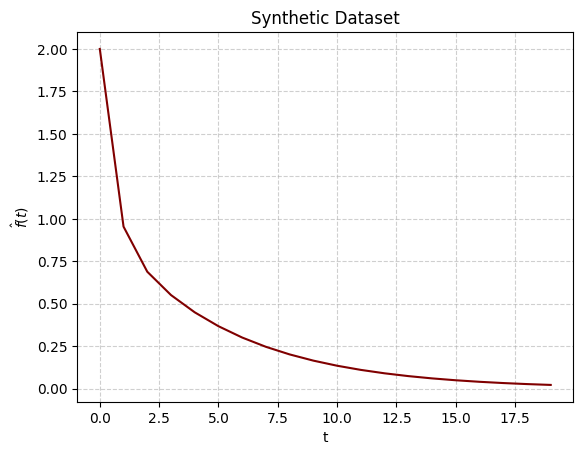

In [6]:
# parameters
a1 = 1.0
a2 = 1.0
b1 = -2.0
b2 = -0.20

# time parameters
t0 = 0
dt = 1 
N = 20

# generating the dataset
t = np.arange(N) * dt 
f = a1 * np.exp(b1*t) + a2 * np.exp(b2*t)

# Print the synthetic dataset
for ti, fi in zip(t, f):
    print(f"t = {ti}, f = {fi}")
    
# plotting the synthetic dataset
plt.plot(t,f,color='maroon')
plt.xlabel('t')
plt.ylabel(r'$\hat{f}(t)$')
plt.title("Synthetic Dataset")
plt.grid(True,linestyle='--',alpha = 0.6)

### Part 2

a1=  0.999999999999999
a2=  1.0000000000000002


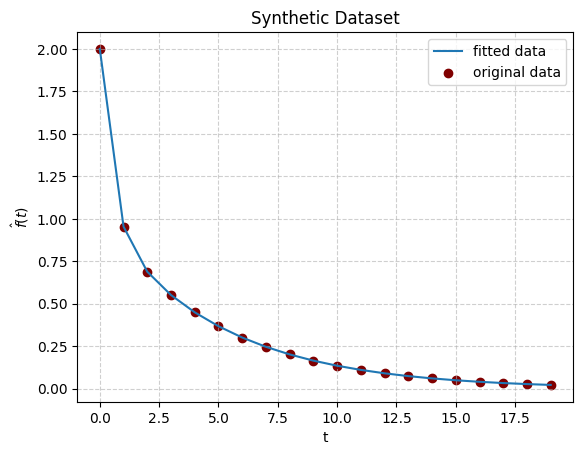

In [17]:
u1 = np.exp(b1*t)
u2 = np.exp(b2*t)

# setting up the matrix for LLS
A = np.zeros([N,2])
for i in range(N):
    A[i,0] = u1[i] 
    A[i,1] = u2[i]

# solving the system A'Ax = A'b 
# x matrix is to be solved and contains a1 and a2 
# f forms matrix b
x = np.linalg.solve(A.transpose() @ A, A.transpose() @ f)
print('a1= ', x[0])
print('a2= ', x[1])

fit = x[0] * u1 + x[1] * u2
plt.plot(t,fit, label='fitted data')
plt.scatter(t,f,color='maroon', label='original data')
plt.xlabel('t')
plt.ylabel(r'$\hat{f}(t)$')
plt.title("Synthetic Dataset")
plt.grid(True,linestyle='--',alpha = 0.6)
plt.legend()

### Part 4

In [30]:
# setting up the matrix for LLS
A = np.zeros([N-2,2])
for i in range(N-2):
    A[i,0] = f[i+1] 
    A[i,1] = f[i]

# solving the system A'Ad = A'b 
# d matrix is to be solved and contains d1 and d2 
# f forms matrix b
d = np.linalg.solve(A.transpose() @ A, A.transpose() @ f[1:N-1])
print("d estimate:")
print('d1 = ', d[0])
print('d2 = ', d[1])

# calculating u1 and u2
u1 = (d[0] + np.sqrt(d[0]*d[0]+4*d[1])) / 2.0
u2 = (d[0] - np.sqrt(d[0]*d[0]+4*d[1])) / 2.0

print("\n")
print("u estimate:")
print('u1 = ', u1)
print('u2 = ', u2)

d estimate:
d1 =  1.0000000000000064
d2 =  -3.8523568342440156e-15


u estimate:
u1 =  1.0000000000000027
u2 =  3.885780586188048e-15


ValueError: x and y must have same first dimension, but have shapes (20,) and (1,)

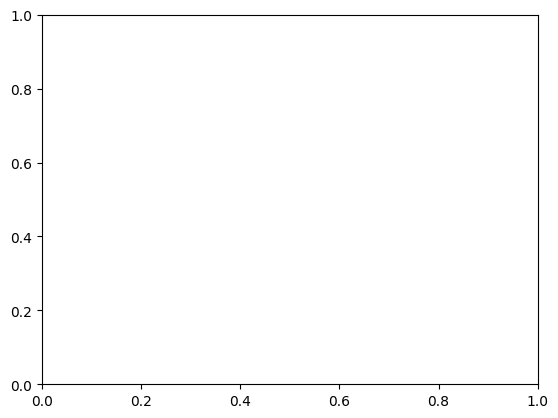